<a href="https://colab.research.google.com/github/f265f9nfmw-droid/Diabetes_Prediction/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset successfully loaded! Shape: (768, 9)


/tmp/ipykernel_1825/3346520647.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


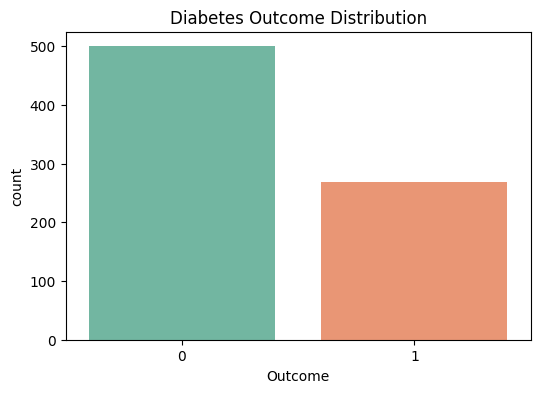

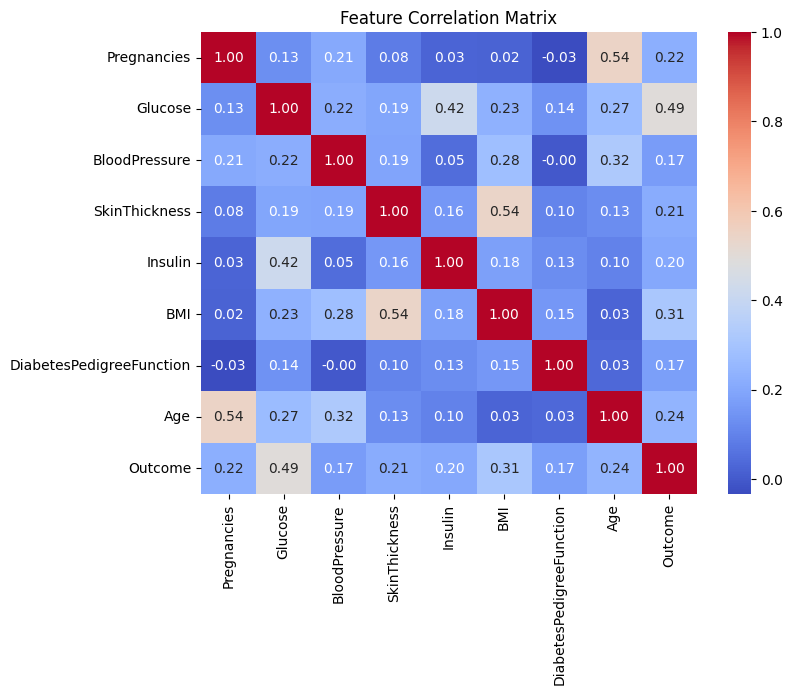


--- Model Performance Comparison ---
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.7078     0.6000  0.5000    0.5455
1        Decision Tree    0.6818     0.5532  0.4815    0.5149
2        Random Forest    0.7792     0.7273  0.5926    0.6531


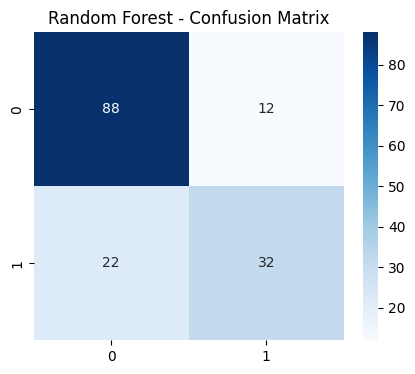

In [3]:
# CBIO313 - Data Mining & Machine Learning Final Project
# Student: Malak Amr | ID: 221001703
# Project: Diabetes Risk Prediction Model

import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Setup Directories
os.makedirs('data', exist_ok=True)
os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

# 1. Load Data (Auto-downloads diabetes.csv if missing)
csv_path = 'data/diabetes.csv'
if not os.path.exists(csv_path):
    print("Downloading diabetes.csv dataset...")
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    colnames = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    df = pd.read_csv(url, header=None, names=colnames)
    df.to_csv(csv_path, index=False)
else:
    df = pd.read_csv(csv_path)

print("Dataset successfully loaded! Shape:", df.shape)

# 2. Data Preprocessing
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_columns] = df[zero_columns].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, 'models/scaler.pkl')

# 3. Exploratory Data Analysis (EDA)
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Diabetes Outcome Distribution')
plt.savefig('figures/target_distribution.png')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.savefig('figures/correlation_heatmap.png')
plt.show()

# 4. Model Training & Evaluation
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4)
    })

joblib.dump(models['Random Forest'], 'models/random_forest.pkl')

# Save Results
results_df = pd.DataFrame(results)
print("\n--- Model Performance Comparison ---")
print(results_df)
results_df.to_csv('results/model_comparison.csv', index=False)

# Plot Confusion Matrix
rf_model = models['Random Forest']
y_pred_rf = rf_model.predict(X_test)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.savefig('figures/confusion_matrix.png')
plt.show()

In [4]:
# 2. Data Preprocessing
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_columns] = df[zero_columns].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, 'models/scaler.pkl')
print("Preprocessing complete! Training set shape:", X_train.shape)

Preprocessing complete! Training set shape: (614, 8)


/tmp/ipykernel_1825/2404874606.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


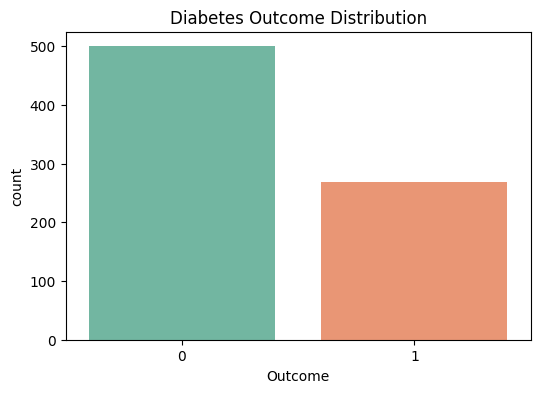

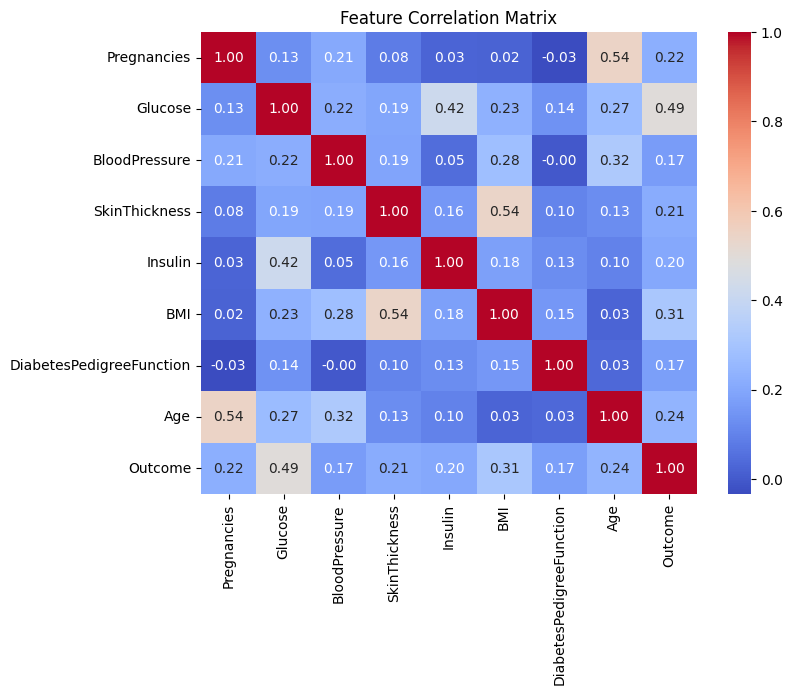

In [5]:
# 3. Exploratory Data Analysis (EDA)
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Diabetes Outcome Distribution')
plt.savefig('figures/target_distribution.png')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.savefig('figures/correlation_heatmap.png')
plt.show()


--- Model Performance Comparison ---
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.7078     0.6000  0.5000    0.5455
1        Decision Tree    0.6818     0.5532  0.4815    0.5149
2        Random Forest    0.7792     0.7273  0.5926    0.6531


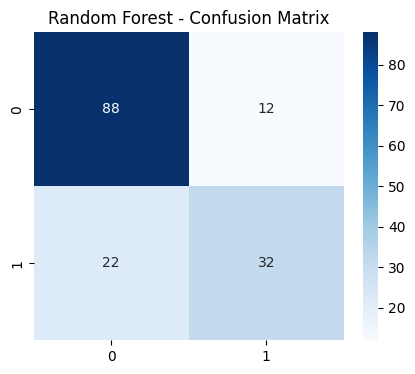

In [6]:
# 4. Model Training & Evaluation
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4)
    })

# Save Best Model (Random Forest)
joblib.dump(models['Random Forest'], 'models/random_forest.pkl')

# Save Results
results_df = pd.DataFrame(results)
print("\n--- Model Performance Comparison ---")
print(results_df)
results_df.to_csv('results/model_comparison.csv', index=False)

# Plot Confusion Matrix for Random Forest
rf_model = models['Random Forest']
y_pred_rf = rf_model.predict(X_test)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.savefig('figures/confusion_matrix.png')
plt.show()